In [ ]:
import pickle
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pickle
import os
import scanpy as sc
import numpy as np
import scperturb
import re, math
import gseapy as gp
import matplotlib.ticker as mticker
import json

In [2]:
from hypermap import HyperMAP
import json
import warnings
from hypermap.evaluate import (
    plot_metric_boxgrid,
    plot_context_boxplot,
    top_genes_global,
    plot_top20_corr_for_gene,
)
warnings.filterwarnings('ignore')

Load processed sciplex data

In [3]:
adata=sc.read_h5ad('data/sciplex_final.h5ad')
#adata.X=adata.X.toarray()
pert_test = adata.obs['condition'][adata.obs['condition']!='ctrl'].unique()
### Columns required context_cell and condition to run
adata.obs.columns=['gene', 'drug', 'dose', 'n_genes', 'context_cell', 'condition'] 
adata=adata[(adata.obs['dose']=='0μM')|(adata.obs['dose']=='10μM')].copy()

In [18]:
## balance low and high number observations
adata = sample_cells(
    adata,
    upper_limit   = 500,
    keep_all_ctrl = False,
    equalize      = True,
)

Cells per context and condition after sampling:

  Context: K562
condition
ctrl                                           500
2-Methoxyestradiol                             500
(+)-JQ1                                        500
A-366                                          500
ABT-737                                        500
Trichostatin A                                 500
Tubastatin A HCl                               500
Tucidinostat                                   500
UNC0379                                        500
UNC0631                                        500
UNC1999                                        500
Valproic acid sodium salt                      500
Vandetanib                                     500
Alendronate sodium trihydrate                  500
Alisertib                                      500
Altretamine                                    500
Alvespimycin (17-DMAG) HCl                     500
Aminoglutethimide                              500
Amisulp

In [22]:
## 1-hot dict
gene_list = adata.obs['condition'][adata.obs['condition']!='ctrl'].unique()
gene_to_index = {gene: i for i, gene in enumerate(gene_list)}

one_hot_dict = {
    gene: np.eye(len(gene_list), dtype=np.float32)[i]  # One-hot vector
    for gene, i in gene_to_index.items()
}


In [34]:
model = HyperMAP(
    adata        = adata,
    gene_emb     = one_hot_dict, ## one-hot or any user defined
    project_name = "drug_run",   # change this name for a fresh cache; allows faster reruns with parameter tuning
    inner_lr = 0.01,    ## Common learning rate for inner loop and adaptation loop
    n_adapt_steps = 3,
    n_adapt_genes = 20,  ## seed perts to use in new context
    seed=1234
)

[HyperMAP] Using device: cuda
[HyperMAP] Computing context-specific control means...
[HyperMAP] Computing delta (normalized expression)...
[HyperMAP] Assigning perturbation embeddings...


100%|██████████| 189/189 [00:00<00:00, 1049.19it/s]


[HyperMAP] Initialised. Contexts: 3  |  Conditions: 189  |  Embedding dim: 188  |  Genes: 2587


Leave one out mode

In [35]:
loo_results = model.loo() 


[LOO] Test context: A549
  [cache] Loading K562...
  [cache] Loading MCF-7...
[HyperMAP] WARNING: 2 training context(s) available — sampling with replacement to fill meta_batch_size=4. For best results, provide more reference contexts (ideally > 8).


Training:   2%|▏         | 1/50 [00:01<01:10,  1.44s/it]

  Epoch 1/50  meta-loss: 76.3008


Training:   4%|▍         | 2/50 [00:03<01:19,  1.65s/it]

  Epoch 2/50  meta-loss: 53.7257


...

Training:  98%|█████████▊| 49/50 [01:23<00:01,  1.75s/it]

  Epoch 49/50  meta-loss: 42.3306


Training: 100%|██████████| 50/50 [01:24<00:00,  1.69s/it]

  Epoch 50/50  meta-loss: 44.6118
  Gene coverage: 188/188 (100.0%)
  [save] Model saved → hypermap_cache/drug_run/model_loo_MCF-7.pt

[LOO] Evaluating MCF-7...


  [adapt] MCF-7  strategy=random  n_adapt_genes=20...
    initial adapt loss: 83.9522
    final adapt loss:   82.2333
  Perts predicted: 188  |  with ground truth: 188  |  NA: 0

[HyperMAP] Run complete.
  Meta-training : 50/50 epochs clean.
  Adaptation    : all 3 context(s) completed successfully.



In [42]:
with open('model_results/sciplex_hypermap.pkl', 'wb') as f:
    pickle.dump(loo_results, f)
print("Saved: model_results/sciplex_hypermap.pkl")

Saved: model_results/sciplex_hypermap.pkl


### Fig 2b-d

In [6]:
with open('data.top_20_sciplex.pkl', 'rb') as file:
        top20 = pickle.load(file)
with open('data/final_results_sciplex.pkl', 'rb') as file:
        scpram = pickle.load(file)

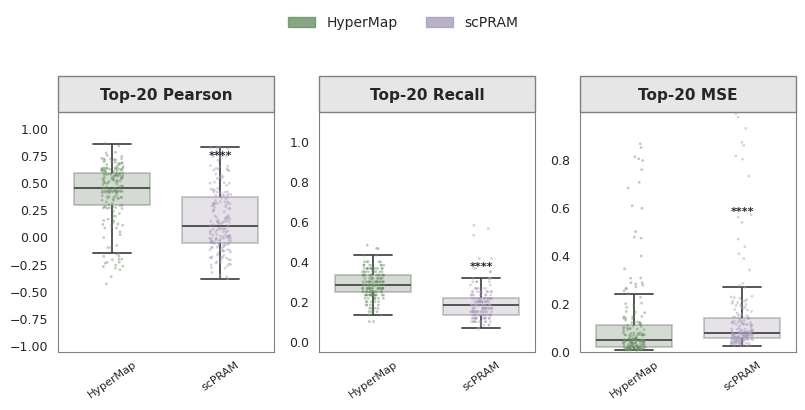

In [9]:
fig, df = plot_metric_boxgrid(
    objs_dict      = {'HyperMap': loo_results ,'scPRAM': scpram},
    colors_dict    = {'HyperMap': '#6a8f65','scPRAM': '#a89cba'},
    models         = ['HyperMap', 'scPRAM'],
    base_model     = 'HyperMap',
    figsize        = (8.5, 4),
    sig_test='mann-whitney',
    top_genes_dict = top20,
)

### Fig 3e-g

[HyperMAP] Figure saved → Figures/Fig3e_g.svg


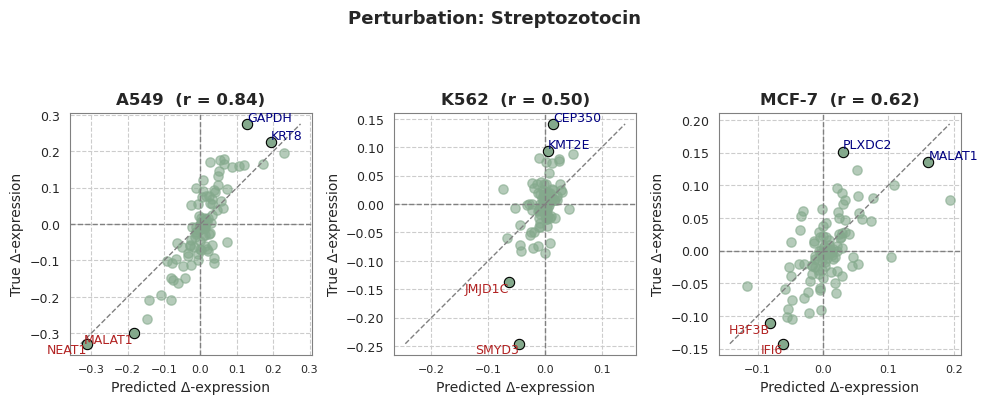

In [9]:
# 3. Top genes for a perturbation
top_genes = top_genes_global(adata, pert='Streptozotocin',
                             contexts=loo_results.keys(),n_top=100)

# 4. Scatter per context for a specific pert
fig = plot_top20_corr_for_gene(
    loaded_object = loo,
    top_20  = top_genes,
    gene          = 'Streptozotocin',
    gene_list     = list(adata.var_names),
    cell        = loo_results.keys(),
)

### Fig 3i-k

In [11]:
gene_embeddings = pd.read_pickle('data/GPT_3_5_gene_embeddings_3-large.pickle')
adata=sc.read_h5ad('data/4_celllines_common.h5ad')
adata.X=adata.X.toarray()
genes=list(gene_embeddings.keys())
genes.append('ctrl')
adata=adata[adata.obs['condition'].isin(genes)]
pert_test = adata.obs['condition'][adata.obs['condition']!='ctrl'].unique()
adata.obs.columns=['gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript',
       'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'n_genes',
       'context_cell', 'condition']

In [6]:
## balance low and high number observations
adata = sample_cells(
    adata,
    upper_limit   = 200,
    keep_all_ctrl = False,
    equalize      = True,
)

/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Cells per cell type and condition after sampling:

Cell Type: rpe1
condition
ctrl        200
AAAS        200
AAMP        200
AARS2       200
AASDHPPT    200
           ... 
ACTR2       200
ACTR3       200
ACTR6       200
ACTR8       200
ACTR10      200
Name: count, Length: 1743, dtype: int64

Cell Type: k562
condition
ctrl        200
AAAS        200
AAMP        200
AARS2       200
AASDHPPT    200
           ... 
ACTR2       200
ACTR3       200
ACTR6       200
ACTR8       200
ACTR10      200
Name: count, Length: 1743, dtype: int64

Cell Type: jurkat
condition
ctrl        200
AAAS        200
AAMP        200
AARS2       200
AASDHPPT    200
           ... 
ACTR2       200
ACTR3       200
ACTR6       200
ACTR8       200
ACTR10      200
Name: count, Length: 1743, dtype: int64

Cell Type: hepg2
condition
ctrl        200
AAAS        200
AAMP        200
AARS2       200
AASDHPPT    200
           ... 
ACTR2       200
ACTR3       200
ACTR6       200
ACTR8       200
ACTR10      200
Name: count, Le

In [11]:
model = HyperMAP(
    adata        = adata1,
    gene_emb     = gene_embeddings,
    project_name = "4cell_run",   # change this name for a fresh cache
    latent_dim   = 64,
    hidden_dim   = 256,
    inner_lr = 0.004,
    n_adapt_steps = 3,
    batch_size=512,
    n_adapt_genes = 20,
    training_epochs=50,
    selection_strategy='random',
    inner_lr_adapt=0.01,
    seed=1234,

)

[HyperMAP] Using device: cuda


/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_1628823/3778439498.py:1: UserWarning: Cache directory 'hypermap_cache/4cell_run' already exists.
Existing cached context data will be reused.
If your data has changed, use a different project_name for a fresh run.
  model = HyperMAP(


[HyperMAP] Computing context-specific control means...
[HyperMAP] Computing delta (normalized expression)...
[HyperMAP] Assigning perturbation embeddings...


100%|██████████| 1743/1743 [00:11<00:00, 146.32it/s]


[HyperMAP] Initialised. Contexts: 4  |  Conditions: 1743  |  Embedding dim: 3072  |  Genes: 2947


In [12]:
loo_results = model.loo()


[LOO] Test context: hepg2
  [cache] Loading jurkat...
  [cache] Loading k562...
  [cache] Loading rpe1...
[HyperMAP] WARNING: 3 training context(s) available — sampling with replacement to fill meta_batch_size=4. For best results, provide more reference contexts (ideally > 8).


Training:   2%|▏         | 1/50 [00:01<01:31,  1.86s/it]

  Epoch 1/50  meta-loss: 299.0864


Training:   4%|▍         | 2/50 [00:03<01:31,  1.91s/it]

  Epoch 2/50  meta-loss: 293.7327


...

Training: 100%|██████████| 50/50 [01:39<00:00,  1.98s/it]

  Epoch 50/50  meta-loss: 313.1348
  Gene coverage: 1742/1742 (100.0%)
  [save] Model saved → hypermap_cache/4cell_run/model_loo_rpe1.pt

[LOO] Evaluating rpe1...


  [adapt] rpe1  strategy=random  n_adapt_genes=20...
    initial adapt loss: 287.2701
    final adapt loss:   280.2348


/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/torch/nn/modules/module.py:811: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1737622248491/work/build/aten/src/ATen/core/TensorBody.h:489.)
  param_grad = param.grad


  Perts predicted: 1742  |  with ground truth: 1742  |  NA: 0

[HyperMAP] Run complete.
  Meta-training : 50/50 epochs clean.
  Adaptation    : all 4 context(s) completed successfully.



In [14]:
with open('model_results/4cell_hypermap.pkl', 'wb') as f:
    pickle.dump(loo_results, f)
print("Saved: model_results/4cell_hypermap.pkl")

Saved: model_results/4cell_hypermap.pkl


In [16]:
with open('data/gears_4cell.pkl', 'rb') as file:
        gears = pickle.load(file)
with open('data/scpram_4cell.json', 'rb') as file:
        scgpt = json.load(file)
with open('data/scgpt_4cell.json', 'rb') as file:
        scgpt = json.load(file)
with open('data/top_20_4cell.pkl', 'rb') as file:
        top = pickle.load(file)

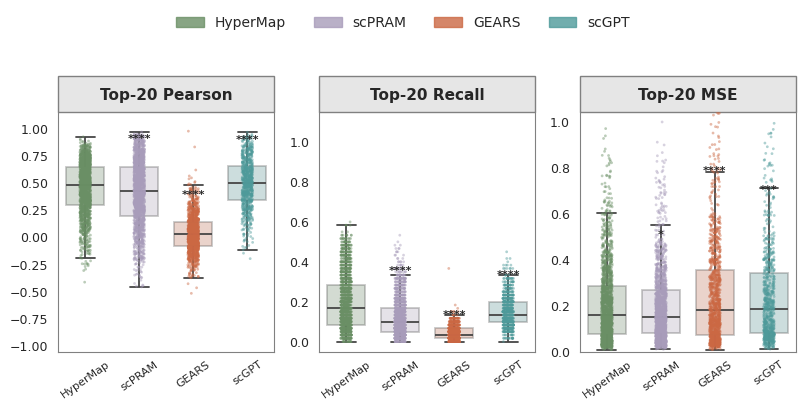

In [22]:
fig, df = plot_metric_boxgrid(
    objs_dict      = {'HyperMap': loo_results, 'GEARS': gears, 'scGPT': scgpt, 'scPRAM': scpram},
    colors_dict    = {'HyperMap': '#6a8f65', 'GEARS': '#cb6843', 'scPRAM': '#a89cba', 'scGPT': '#4e9a9a'},
    models         = ['HyperMap', 'scPRAM', 'GEARS', 'scGPT'],
    base_model     = 'HyperMap',
    figsize        = (8.5, 4),
    sig_test='mann-whitney',
    top_genes_dict=top,
)

### Fig l-n

[HyperMAP] Figure saved → Figures/Fig3l_n.svg


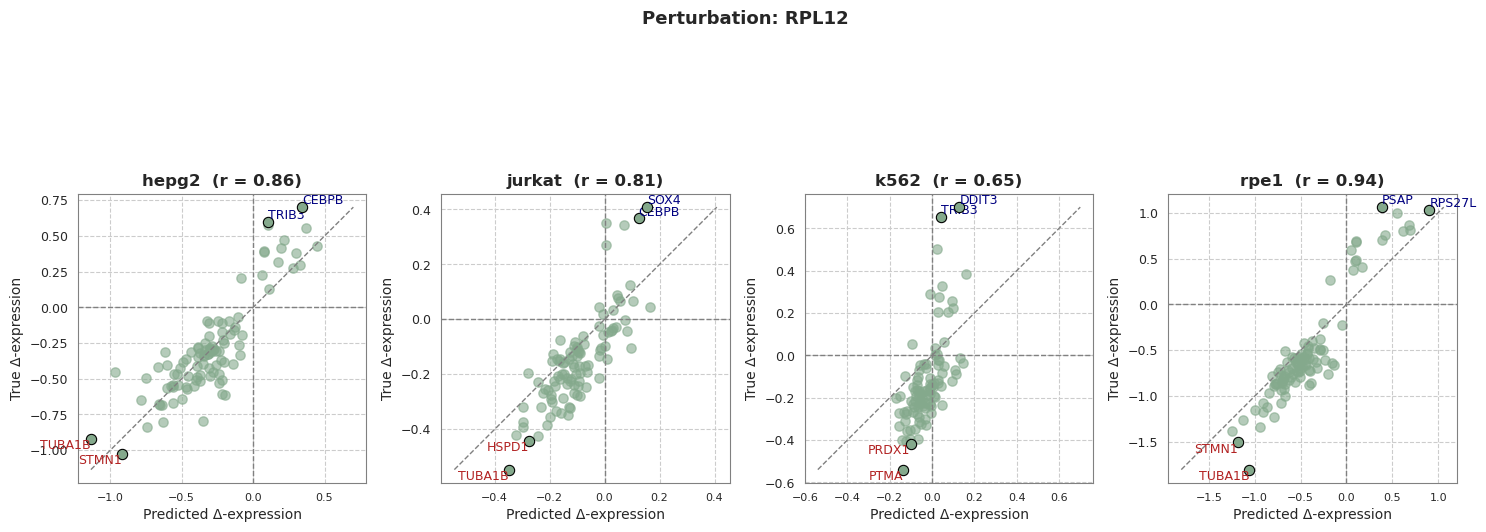

In [21]:
# 3. Top genes for a perturbation
top_genes = top_genes_global(adata, pert='RPL12',
                             contexts=loo_results.keys(),n_top=100)

# 4. Scatter per context for a specific pert
fig = plot_top20_corr_for_gene(
    loaded_object = loo_results,
    top_20_donor  = top_genes,
    gene          = 'RPL12',
    gene_list     = list(adata.var_names),
    donors        = loo_results.keys(),
    figsize = (15, 6),
)